Notebook for analysis of experimental results for number of perturbation directions `P`.

`./scripts/runpexp` was ran with 3 different seeds beforehand.


In [91]:
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "runs").exists():
    project_root = project_root.parent

experiments = ["experiment_p_20260614_085722", "experiment_p_20260614_085721"]

EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in experiments]

# list of all subdirectories, instead of the logs
experiments = []
for exp_dir in EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs"):
            experiments.append(str(subdir.relative_to(project_root)))

print(len(experiments))
experiments


24


['runs/experiment_p_20260614_085722/dd_cnn_fashionmnist_P2_proj16_20260614_155333_seed456',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P2_20260614_150330_seed123',
 'runs/experiment_p_20260614_085722/dd_cnn_fashionmnist_P1_proj16_20260614_153735_seed456',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P4_20260614_151330_seed123',
 'runs/experiment_p_20260614_085722/dd_cnn_fashionmnist_P8_proj16_20260614_170030_seed456',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P1_20260614_181553_seed456',
 'runs/experiment_p_20260614_085722/dd_cnn_fashionmnist_P2_proj16_20260614_123328_seed123',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P1_20260614_145439_seed123',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P2_20260614_182548_seed456',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P8_20260614_152439_seed123',
 'runs/experiment_p_20260614_085722/dd_mlp_fashionmnist_P8_20260614_184635_seed456',
 'runs/experiment_p_20260614_085722/d

In [93]:
import matplotlib

FIGURES_DIR = project_root / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

matplotlib.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
    }
)

In [94]:
results = [str((project_root / "results" / Path(e).name).relative_to(project_root)) + ".json" for e in experiments]
results

['results/dd_cnn_fashionmnist_P2_proj16_20260614_155333_seed456.json',
 'results/dd_mlp_fashionmnist_P2_20260614_150330_seed123.json',
 'results/dd_cnn_fashionmnist_P1_proj16_20260614_153735_seed456.json',
 'results/dd_mlp_fashionmnist_P4_20260614_151330_seed123.json',
 'results/dd_cnn_fashionmnist_P8_proj16_20260614_170030_seed456.json',
 'results/dd_mlp_fashionmnist_P1_20260614_181553_seed456.json',
 'results/dd_cnn_fashionmnist_P2_proj16_20260614_123328_seed123.json',
 'results/dd_mlp_fashionmnist_P1_20260614_145439_seed123.json',
 'results/dd_mlp_fashionmnist_P2_20260614_182548_seed456.json',
 'results/dd_mlp_fashionmnist_P8_20260614_152439_seed123.json',
 'results/dd_mlp_fashionmnist_P8_20260614_184635_seed456.json',
 'results/dd_cnn_fashionmnist_P8_proj16_20260614_133938_seed123.json',
 'results/dd_cnn_fashionmnist_P1_proj16_20260614_121726_seed123.json',
 'results/dd_mlp_fashionmnist_P4_20260614_183548_seed456.json',
 'results/dd_cnn_fashionmnist_P4_proj16_20260614_161841_seed45

In [95]:
from tbparse import SummaryReader
from typing import List, Dict

raw_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in EXPERIMENT_DIRS
]
df_all = pd.concat(raw_dfs, ignore_index=True)

df_all = df_all.assign(
    wall_clock=pd.to_datetime(df_all["wall_time"], unit="s", utc=True),
    architecture=df_all["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    num_perturbations=df_all["dir_name"].str.extract(r"_P(\d+)_")[0].astype(int),
    seed=df_all["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time", "dir_name"])

arch_dfs: Dict[str, pd.DataFrame] = {
    arch: sub_df.drop(columns=["architecture"]).reset_index(drop=True)
    for arch, sub_df in df_all.groupby("architecture")
}

df_mlp, df_cnn = arch_dfs["mlp"], arch_dfs["cnn"]

In [96]:
# HELPER FUNCTIONS
def aggregate_over_seeds(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(["tag", "num_perturbations", "step"])["value"].agg(mean="mean", std="std").reset_index()


def plot_tags(agg: pd.DataFrame, tags: list, arch_name: str, save_name: str = None):
    p_values = sorted(agg["num_perturbations"].unique())
    fig, axes = plt.subplots(1, len(tags), figsize=(5 * len(tags), 4), squeeze=False)

    for i, tag in enumerate(tags):
        ax = axes[0][i]
        for p in p_values:
            sub = agg[(agg["tag"] == tag) & (agg["num_perturbations"] == p)].sort_values("step")
            ax.plot(sub["step"], sub["mean"], label=f"P={p}")
            ax.fill_between(
                sub["step"],
                sub["mean"] - sub["std"],
                sub["mean"] + sub["std"],
                alpha=0.2,
            )
        ax.set_title(tag.replace("dd/", ""), fontsize=9)
        ax.set_xlabel("Step")
        ax.set_ylabel("mean +- std")
        ax.legend(fontsize=7)

    fig.suptitle(arch_name.upper(), fontsize=12)
    plt.tight_layout()
    if save_name:
        fig.savefig(FIGURES_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()

## MLP


In [97]:
df_mlp.iloc[[0, 10, 100, 500, 10000]]

,step,tag,value,wall_clock,num_perturbations,seed
0,1,dd/layer_acc/layer_0/train,0.448315,2026-06-14 12:54:48.619419813+00:00,1,123
10,11,dd/layer_acc/layer_0/train,0.756278,2026-06-14 12:55:11.590149879+00:00,1,123
100,101,dd/layer_acc/layer_0/train,0.806741,2026-06-14 12:58:42.304157019+00:00,1,123
500,101,dd/layer_acc/layer_1/train,0.765333,2026-06-14 12:58:42.304292917+00:00,1,123
10000,1,dd/layer_loss/layer_2/train,2.317312,2026-06-14 13:03:41.530104160+00:00,2,123


In [98]:
mlp_agg = aggregate_over_seeds(df_mlp)
mlp_agg.head()

,tag,num_perturbations,step,mean,std
0,dd/layer_acc/layer_0/train,1,1,0.461914,0.018530
1,dd/layer_acc/layer_0/train,1,2,0.647352,0.008683
2,dd/layer_acc/layer_0/train,1,3,0.685451,0.004746
3,dd/layer_acc/layer_0/train,1,4,0.708562,0.003633
4,dd/layer_acc/layer_0/train,1,5,0.725049,0.005628


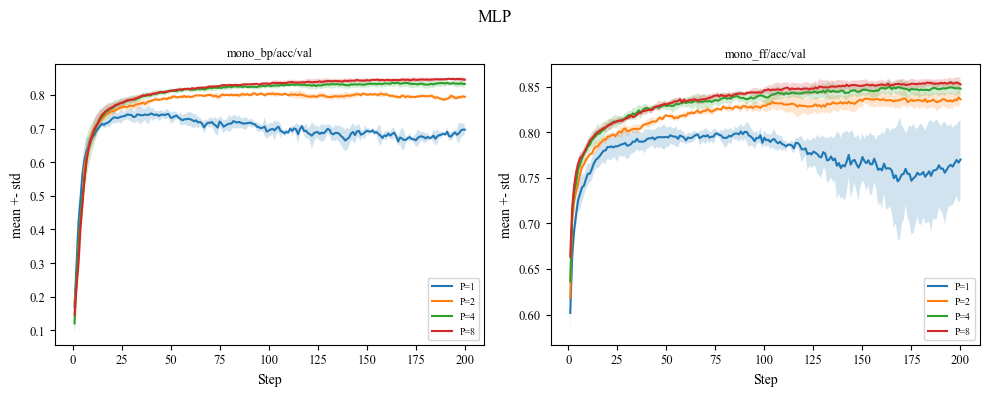

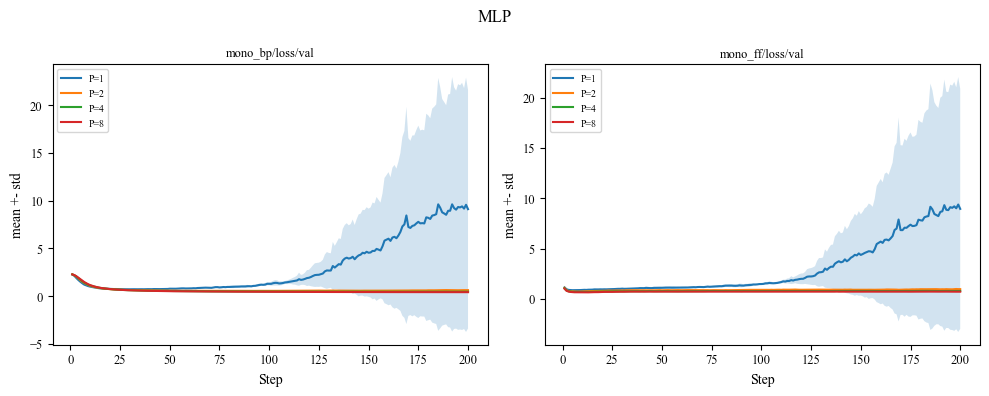

In [99]:
plot_tags(mlp_agg, ["dd/mono_bp/acc/val", "dd/mono_ff/acc/val"], "mlp", save_name="mlp_val_acc_vs_P")
plot_tags(mlp_agg, ["dd/mono_bp/loss/val", "dd/mono_ff/loss/val"], "mlp", save_name="mlp_val_loss_vs_P")

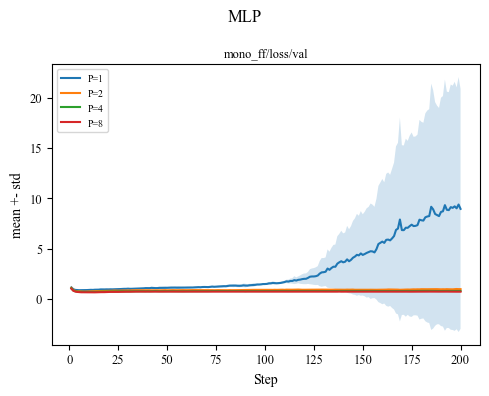

In [100]:
plot_tags(mlp_agg, ["dd/mono_ff/loss/val"], "mlp", save_name="mlp_ff_val_loss_vs_P")

#### Test Result table


In [101]:
from pathlib import Path


def parse_result(res_path: str) -> tuple[str, int]:
    stem = Path(res_path).stem
    parts = stem.split("_")
    num_perturbations = int(parts[3].removeprefix("P"))
    seed = int(parts[-1].removeprefix("seed"))
    return num_perturbations, seed


res_dfs = []
mlp_results = filter(lambda res: "_mlp_" in res, results)

for res in mlp_results:
    res_df = pd.read_json(project_root / res)
    num_perturbations, seed = parse_result(res)
    res_df = res_df.assign(
        num_perturbations=num_perturbations,
        seed=seed,
    )

    # drop best epoch rows and early stopping columns
    res_df.drop(columns=["early_stopping"], inplace=True)
    res_df.drop(["best_epoch", "stopped_epoch"], axis=0, inplace=True)

    res_dfs.append(res_df)

res_df = pd.concat(res_dfs, ignore_index=True)
res_df.head()


,mono_ff,mono_bp,num_perturbations,seed
0,0.8263,0.7864,2,123
1,0.8389,0.8203,4,123
2,0.7149,0.6960,1,456
3,0.7975,0.7048,1,123
4,0.8272,0.7878,2,456


In [102]:
res_agg = res_df.groupby("num_perturbations")[["mono_ff", "mono_bp"]].agg(["mean", "std"])

res_agg.columns = [f"{col}_{stat}" for col, stat in res_agg.columns]
print(res_agg)
mlp_res_agg = res_agg


                   mono_ff_mean  mono_ff_std  mono_bp_mean  mono_bp_std
num_perturbations                                                      
1                      0.765100     0.044083      0.693033     0.013497
2                      0.825900     0.001539      0.785567     0.002747
4                      0.837167     0.002194      0.820567     0.000252
8                      0.845433     0.002572      0.838200     0.000300


## CNN


In [103]:
cnn_agg = aggregate_over_seeds(df_cnn)
cnn_agg.head()

,tag,num_perturbations,step,mean,std
0,dd/layer_acc/layer_0/train,1,1,0.186130,0.032961
1,dd/layer_acc/layer_0/train,1,2,0.339204,0.010615
2,dd/layer_acc/layer_0/train,1,3,0.442321,0.011096
3,dd/layer_acc/layer_0/train,1,4,0.510012,0.019090
4,dd/layer_acc/layer_0/train,1,5,0.552395,0.020350


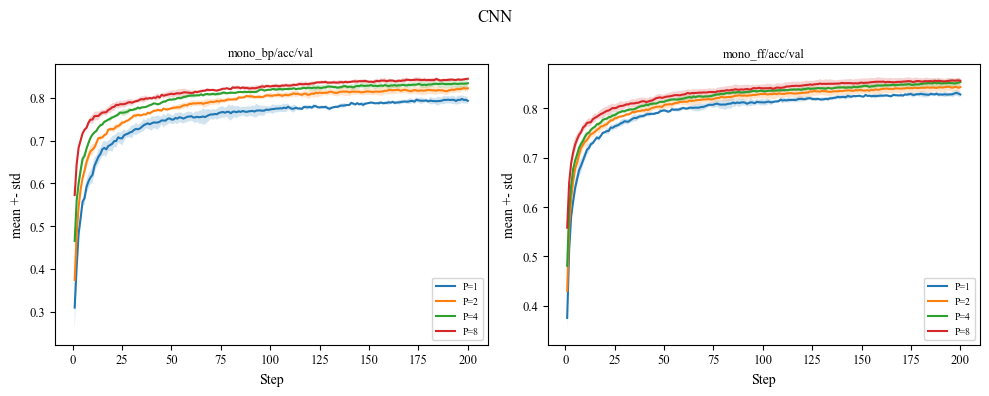

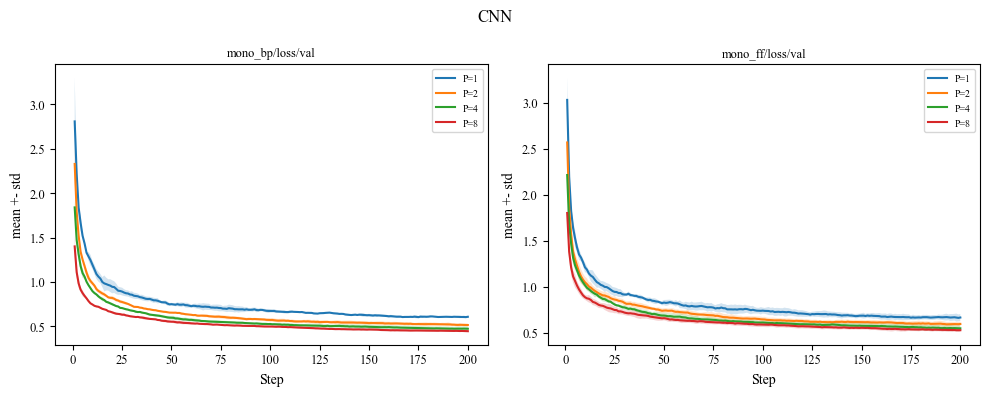

In [104]:
plot_tags(cnn_agg, ["dd/mono_bp/acc/val", "dd/mono_ff/acc/val"], "cnn", save_name="cnn_val_acc_vs_P")
plot_tags(cnn_agg, ["dd/mono_bp/loss/val", "dd/mono_ff/loss/val"], "cnn", save_name="cnn_val_loss_vs_P")

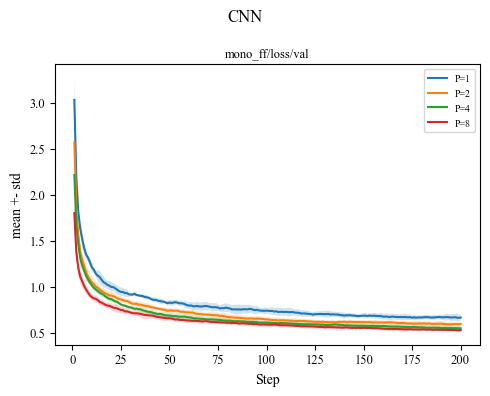

In [109]:
plot_tags(cnn_agg, ["dd/mono_ff/loss/val"], "cnn", save_name="cnn_ff_val_loss_vs_P")


In [106]:
res_dfs = []
cnn_results = filter(lambda res: "_cnn_" in res, results)

for res in cnn_results:
    res_df = pd.read_json(project_root / res)
    num_perturbations, seed = parse_result(res)
    res_df = res_df.assign(
        num_perturbations=num_perturbations,
        seed=seed,
    )

    # drop best epoch rows and early stopping columns
    res_df.drop(columns=["early_stopping"], inplace=True)
    res_df.drop(["best_epoch", "stopped_epoch"], axis=0, inplace=True)

    res_dfs.append(res_df)

res_df = pd.concat(res_dfs, ignore_index=True)
res_df.head()


,mono_ff,mono_bp,num_perturbations,seed
0,0.8341,0.8138,2,456
1,0.8174,0.7800,1,456
2,0.8456,0.8381,8,456
3,0.8328,0.8097,2,123
4,0.8476,0.8362,8,123


In [107]:
res_agg = res_df.groupby("num_perturbations")[["mono_ff", "mono_bp"]].agg(["mean", "std"])

res_agg.columns = [f"{col}_{stat}" for col, stat in res_agg.columns]
print(res_agg)
cnn_res_agg = res_agg


                   mono_ff_mean  mono_ff_std  mono_bp_mean  mono_bp_std
num_perturbations                                                      
1                      0.818967     0.001358      0.784833     0.006037
2                      0.832933     0.001106      0.811300     0.002193
4                      0.841733     0.004373      0.827133     0.003213
8                      0.846433     0.001041      0.835800     0.002524


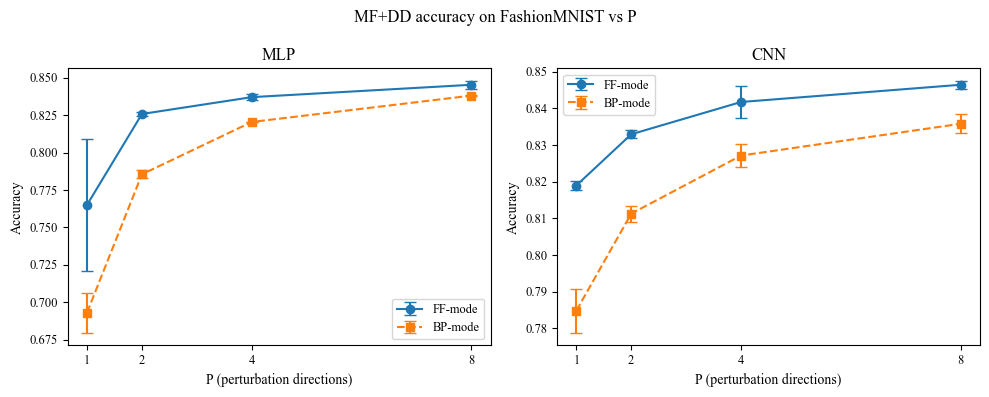

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, agg, title in zip(axes, [mlp_res_agg, cnn_res_agg], ["MLP", "CNN"]):
    P = agg.index.tolist()
    ax.errorbar(
        P,
        agg["mono_ff_mean"],
        yerr=agg["mono_ff_std"],
        marker="o",
        capsize=4,
        label="FF-mode",
    )
    ax.errorbar(
        P,
        agg["mono_bp_mean"],
        yerr=agg["mono_bp_std"],
        marker="s",
        capsize=4,
        linestyle="--",
        label="BP-mode",
    )
    ax.set_title(title)
    ax.set_xlabel("P (perturbation directions)")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(P)
    ax.legend()

fig.suptitle("MF+DD accuracy on FashionMNIST vs P")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "acc_vs_P.pdf", bbox_inches="tight")
plt.show()